# Correlating C02 Emissions and Global Temperature Anomalies

## Import Modules and Define variables

In [ ]:

import plotly.express as px
import pandas as pd

# Define variables
start_year = 1850
end_year = 2021
START_YEAR = 1850
END_YEAR = 2021
coefficient_of_correlation=0


## Line Chart Yearly Emissions from Fossil Fuel Consumption and Cement Production (1850-2021)
This data is available for years 1751-2021, but filtered to 1850-2021 in order to compare with tempature anomoly data.

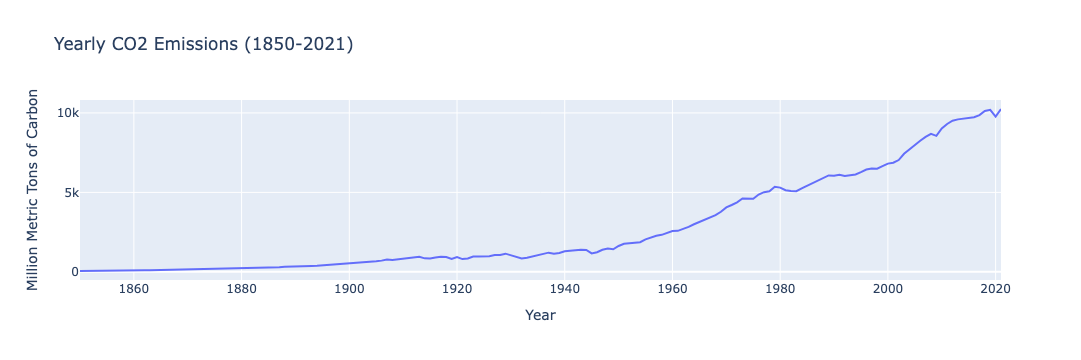

In [3]:
# Emissions data URL
EMISSIONS_DATA = 'https://raw.githubusercontent.com/plotly/Figure-Friday/'\
        'refs/heads/main/2025/week-21/global.1751_2021.csv'
# Read data from CSV file
df_emissions_1850_2021=  pd.read_csv(EMISSIONS_DATA,encoding='utf8')
# df_emission_line = pd.read_csv(EMISSIONS_DATA,encoding='utf8')
# Filter data for the specified year range (1850-2021)
df_filtered_emissions_1850_2021 = df_emissions_1850_2021[(df_emissions_1850_2021['Year'] >= START_YEAR) & (df_emissions_1850_2021['Year'] <= END_YEAR)]
# Set up CSV data column name constants for access by name
LINE_X_COL_NAME = 'Year'
# Name of column in emissions data CSV file
LINE_Y_COL_NAME = 'Total carbon emissions from fossil fuel consumption and cement production (million metric tons of C)'
# Create line chart using Plotly Express
line_fig = px.line(
    df_filtered_emissions_1850_2021,
    x=LINE_X_COL_NAME,
    y=LINE_Y_COL_NAME, 
    title='Yearly CO2 Emissions (1850-2021)',
    labels={LINE_Y_COL_NAME: "CO2 Emissions (MtC)"}
)

# Set the y-axis title
LINE_Y_AXIS_TITLE = "Million Metric Tons of Carbon"
line_fig.update_layout(yaxis_title=LINE_Y_AXIS_TITLE)
line_fig.show()

# df_filtered_emissions_1850_2021.tail()

## Bar chart showing temperature anomalies by range of years

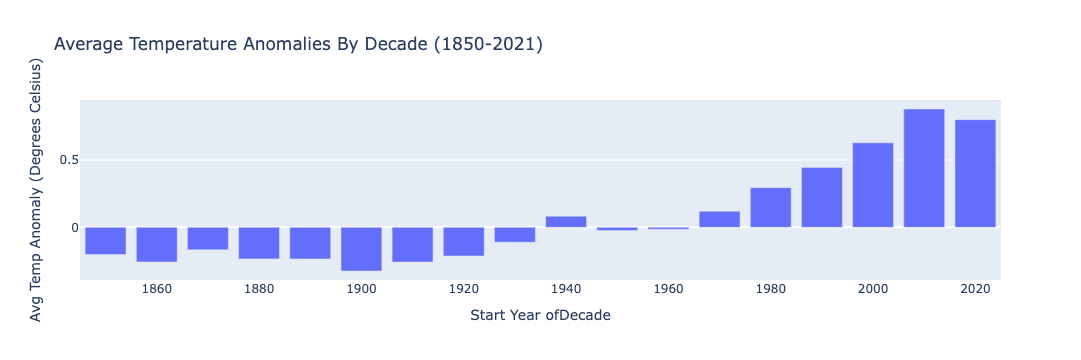

In [4]:
# BAR CHART: Temperature Anomalies by Year

# Temp Anomalies Filtering
TEMP_ANOMALIES_DATA = '../data/global_temp_anomaly.csv'
# Read temp anomaly data
df_temp_anomaly = pd.read_csv(TEMP_ANOMALIES_DATA,comment='#',encoding='utf8')

# filter data for the specified year range (1850-2021)
df_filtered_temp_anomalies_1850_2021 = \
    df_temp_anomaly[(df_temp_anomaly\
    ['Year']>= START_YEAR) & (df_temp_anomaly['Year'] <= END_YEAR)]

# set up title constant
TEMP_ANOMALIES_TITLE = 'Average Temperature Anomalies By Decade (1850-2021)' 
# set up filtering with column name constant
ANOMALY_COL_NAME = 'Anomaly'

# Create bins to feed bar chart
# Create a copy to add binned data to
df_filtered_temp_anomalies_1850_2021_COPY = df_filtered_temp_anomalies_1850_2021.copy()
# Create bins for decades - make the end year 1 greater than the last year to include
bins = pd.interval_range(start=1850, end=2030, freq=10, closed='right')  # 10-year bins
# Add a final bin to cover 2021
# bins = bins.append(pd.Interval(left=2020, right=2021, closed='right'))
# print(bins)

# Add a new column to the DataFrame with the binned years
df_filtered_temp_anomalies_1850_2021_COPY['Year_bin'] = pd.cut(\
    df_filtered_temp_anomalies_1850_2021_COPY['Year'], bins)
# print(df_filtered_temp_anomalies_1850_2021_COPY)

# Group by bin and calculate mean anomaly
grouped = df_filtered_temp_anomalies_1850_2021_COPY.groupby('Year_bin', observed=True)['Anomaly'].mean().reset_index()
# print(grouped)

# Plot with Plotly Express
# Convert Interval to string for better x-axis labeling 
# and allowing Plotly to serialze it
#######grouped['Year_bin'] = grouped['Year_bin'].astype(str)
grouped['Year_bin_start'] = grouped['Year_bin']\
    .apply(lambda x: int(x.left))
bar_fig = px.bar(grouped, x='Year_bin_start', y='Anomaly', title=TEMP_ANOMALIES_TITLE)

# bar_fig = px.bar(grouped, x='Year_bin', y='Anomaly', title='Average Temperature Anomaly by Decade')
BAR_Y_AXIS_TITLE = "Avg Temp Anomaly\n(Degrees Celsius)"
BAR_X_AXIS_TITLE = "Start Year ofDecade"
bar_fig.update_layout(xaxis_title=BAR_X_AXIS_TITLE)
bar_fig.update_layout(yaxis_title=BAR_Y_AXIS_TITLE)
bar_fig.show()



## Correlation of Increasing C02 Emissions and Temperature Anomalies

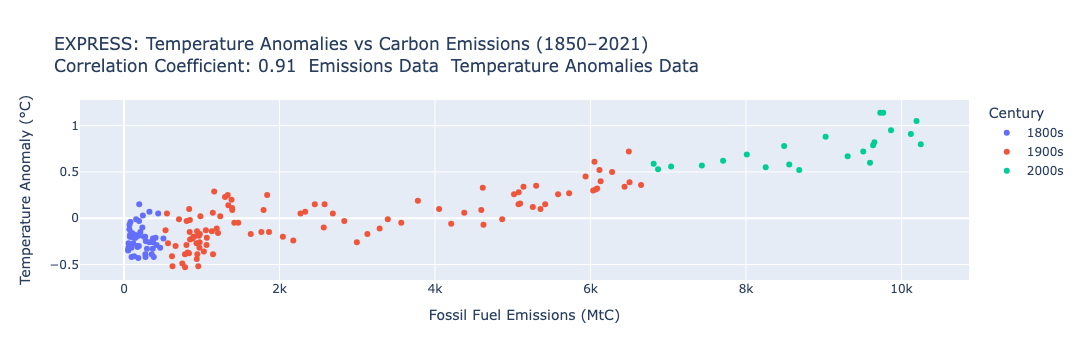

In [5]:
# Scatterpolot and CORRELATION: Do temperature anomalies increase with increased C02 emissions


# Merge both DataFrames on 'Year'
df_merged = pd.merge(df_filtered_emissions_1850_2021, df_filtered_temp_anomalies_1850_2021, on='Year')

# Get list of years from merged
df_years = df_merged[['Year']].copy()

# Add century to df merged
df_merged['Century'] = ((df_merged['Year'] // 100) * 100).astype(str) + 's'


# Get Correllation Coefficient
coefficient_of_correlation = \
    df_filtered_emissions_1850_2021[LINE_Y_COL_NAME].corr(df_filtered_temp_anomalies_1850_2021[ANOMALY_COL_NAME])
TEMP_ANOMALIES_TITLE = 'Temperature Anomalies vs Carbon Emissions (1850–2021)'\
          f'<br>Correlation Coefficient: {coefficient_of_correlation:.2f}'\
          f'  <a href="{EMISSIONS_DATA}" target=_blank>Emissions Data</a>'\
          f'  <a href="{TEMP_ANOMALIES_DATA}" target=_blank>Temperature Anomalies Data</a>'

# for i in range(5):
#     print('Emmissons:',df_merged[EMISSION_COL_NAME][i], 
#           'Temp Anomalie:',df_merged[ANOMALY_COL_NAME][i],
#           'Century:',df_merged['Century'][i])

# Plot scatterplot

# Scatterplot using Express
scatterplot_x_fig = px.scatter(
    df_merged,
    x=LINE_Y_COL_NAME,
    y=ANOMALY_COL_NAME,
    color='Century', 
    labels={
        LINE_Y_COL_NAME: 'Fossil Fuel Emissions (MtC)',
        ANOMALY_COL_NAME: 'Temperature Anomaly (°C)'
    },
    title= 'EXPRESS: ' + TEMP_ANOMALIES_TITLE
)
scatterplot_x_fig.show()


# Scatterplot using Graph Objects
# centuries = df_merged['Century'].unique()
# colors = ['blue','red','green']  # Choose your own colors

# Create a dictionary mapping categories to colors
# color_map = dict(zip(centuries, colors))

# scatterplot_go_fig = go.Figure(data=[go.Scatter(
#     x=df_merged[LINE_Y_COL_NAME],
#     y=df_merged[ANOMALY_COL_NAME],
#     mode='markers',
#     marker=dict(
#         color=df_merged['Century'].map(color_map), # Use the mapping
#         size=6
#     )
# )])
# # Customize layout (optional)
# scatterplot_go_fig.update_layout(
#     title='GO: ' + TEMP_ANOMALIES_TITLE,
#     xaxis_title='Fossil Fuel Emissions (MtC)',
#     yaxis_title='Temperature Anomaly (°C)'
# )

# scatterplot_go_fig.show()


## Show All Three Graphs: Line, Bar, Scatterplot

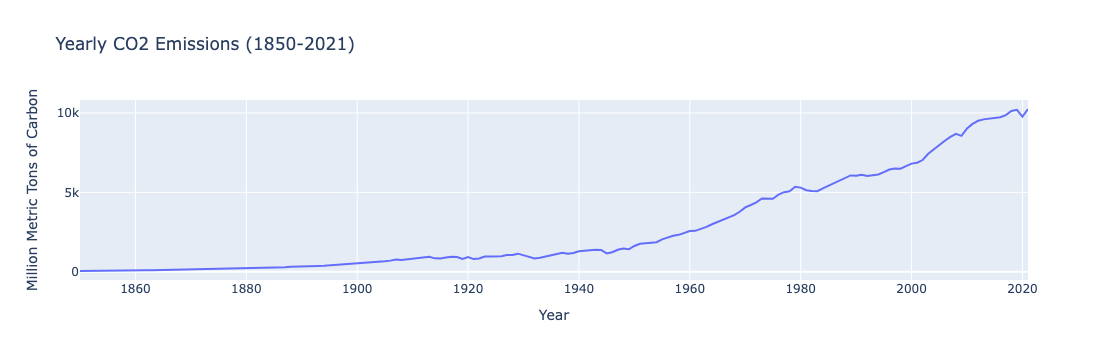

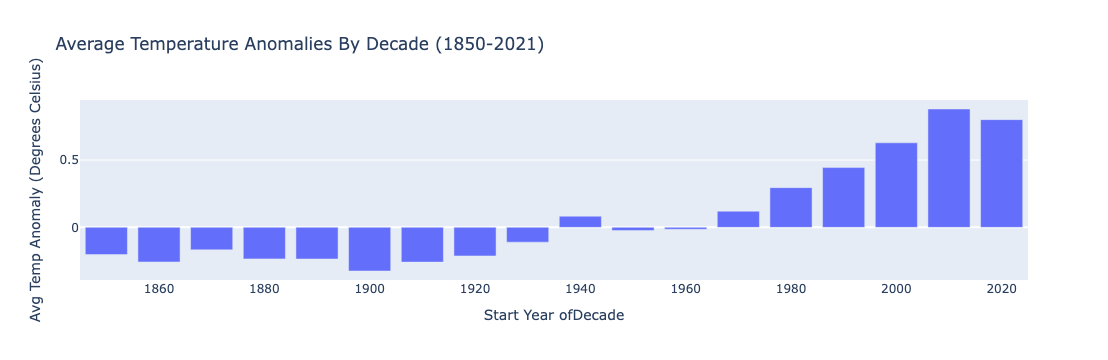

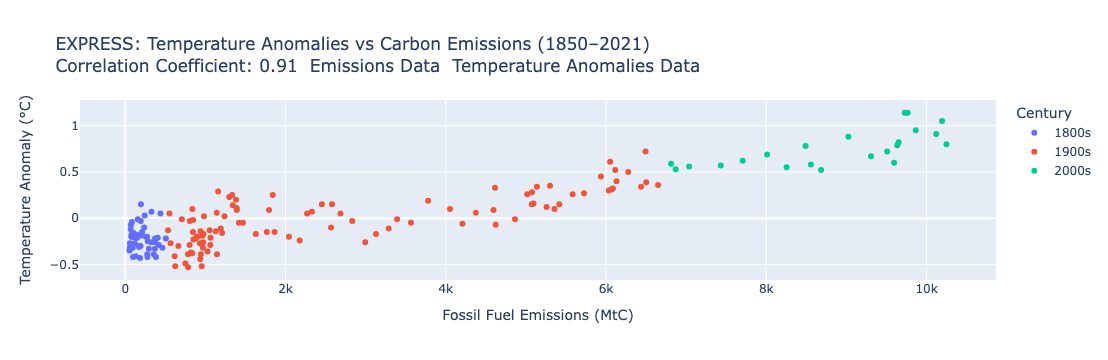

In [6]:

line_fig.show()
line_fig.write_html('line_fig.html')

bar_fig.show()
bar_fig.write_html('bar_fig.html')

scatterplot_x_fig.show()
scatterplot_x_fig.write_html('scatterplot_x_fig.html')
